# 1) Imports


In [7]:
import json
import pickle
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 2) Feature Engineering


In [8]:
DATE_COLS = {
    "transaction_date",
    "membership_expire_date",
    "registration_init_time",
    "expiration_date",
    "date",
}


def load_first_existing(data_dir: Path, names: Iterable[str]) -> pd.DataFrame:
    for name in names:
        path = data_dir / name
        if path.exists():
            return pd.read_csv(path)
    raise FileNotFoundError(f"None of these files were found in {data_dir}: {list(names)}")


def parse_dates(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c in out.columns:
        if c in DATE_COLS:
            out[c] = pd.to_datetime(out[c], format="%Y%m%d", errors="coerce")
    return out


def build_transaction_features(transactions: pd.DataFrame) -> pd.DataFrame:
    tx = parse_dates(transactions)
    tx = tx.sort_values(["msno", "transaction_date"]).copy()

    latest = tx.groupby("msno", as_index=False).tail(1)

    aggs = tx.groupby("msno").agg(
        tx_count=("msno", "size"),
        avg_plan_days=("payment_plan_days", "mean"),
        avg_list_price=("plan_list_price", "mean"),
        avg_paid=("actual_amount_paid", "mean"),
        auto_renew_rate=("is_auto_renew", "mean"),
        cancel_rate=("is_cancel", "mean"),
        last_tx_date=("transaction_date", "max"),
        last_membership_expire=("membership_expire_date", "max"),
    )

    aggs["days_between_tx_and_expire"] = (
        aggs["last_membership_expire"] - aggs["last_tx_date"]
    ).dt.days

    latest = latest[[
        "msno",
        "payment_method_id",
        "payment_plan_days",
        "plan_list_price",
        "actual_amount_paid",
        "is_auto_renew",
        "is_cancel",
    ]].rename(columns={
        "payment_method_id": "latest_payment_method_id",
        "payment_plan_days": "latest_payment_plan_days",
        "plan_list_price": "latest_plan_list_price",
        "actual_amount_paid": "latest_amount_paid",
        "is_auto_renew": "latest_is_auto_renew",
        "is_cancel": "latest_is_cancel",
    })

    out = aggs.reset_index().merge(latest, on="msno", how="left")
    out["avg_discount"] = out["avg_list_price"] - out["avg_paid"]
    out["latest_discount"] = out["latest_plan_list_price"] - out["latest_amount_paid"]
    return out


def build_log_features(user_logs: pd.DataFrame) -> pd.DataFrame:
    logs = parse_dates(user_logs)
    logs = logs.sort_values(["msno", "date"]).copy()

    logs["engagement_total_plays"] = (
        logs[["num_25", "num_50", "num_75", "num_985", "num_100"]].sum(axis=1)
    )
    logs["completion_ratio"] = logs["num_100"] / (logs["engagement_total_plays"] + 1e-6)

    agg = logs.groupby("msno").agg(
        log_days=("date", "nunique"),
        avg_plays=("engagement_total_plays", "mean"),
        avg_unq=("num_unq", "mean"),
        avg_total_secs=("total_secs", "mean"),
        avg_completion_ratio=("completion_ratio", "mean"),
        last_log_date=("date", "max"),
    )

    recent_window = logs[logs["date"] >= (logs["date"].max() - pd.Timedelta(days=30))]
    recent = recent_window.groupby("msno").agg(
        recent_30d_plays=("engagement_total_plays", "sum"),
        recent_30d_secs=("total_secs", "sum"),
        recent_30d_days=("date", "nunique"),
    )

    return agg.join(recent, how="left").reset_index()


def build_member_features(members: pd.DataFrame) -> pd.DataFrame:
    mem = parse_dates(members)
    out = mem.copy()

    if "bd" in out:
        out["bd"] = out["bd"].where(out["bd"].between(10, 90), np.nan)

    if "registration_init_time" in out:
        ref_date = out["registration_init_time"].max()
        out["days_since_registration"] = (ref_date - out["registration_init_time"]).dt.days

    return out


# 3) Training Table


In [9]:
def create_training_table(data_dir: Path) -> pd.DataFrame:
    train = load_first_existing(data_dir, ["train_v2.csv", "train.csv"])
    transactions = load_first_existing(data_dir, ["transactions_v2.csv", "transactions.csv"])
    user_logs = load_first_existing(data_dir, ["user_logs_v2.csv", "user_logs.csv"])
    members = load_first_existing(data_dir, ["members_v3.csv", "members.csv"])

    tx_feat = build_transaction_features(transactions)
    log_feat = build_log_features(user_logs)
    mem_feat = build_member_features(members)

    df = train.merge(tx_feat, on="msno", how="left")
    df = df.merge(log_feat, on="msno", how="left")
    df = df.merge(mem_feat, on="msno", how="left")
    return df


# 4) LogReg


In [10]:
def build_model(df: pd.DataFrame):
    y = df["is_churn"].astype(int)
    msno = df["msno"]
    X = df.drop(columns=["is_churn", "msno"])

    datetime_cols = [c for c in X.columns if np.issubdtype(X[c].dtype, np.datetime64)]
    X = X.drop(columns=datetime_cols)

    cat_cols = [c for c in X.columns if X[c].dtype == "object"]
    num_cols = [c for c in X.columns if c not in cat_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), num_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]), cat_cols),
        ],
        remainder="drop",
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=600, class_weight="balanced")),
    ])

    X_train, X_test, y_train, y_test, msno_train, msno_test = train_test_split(
        X, y, msno, test_size=0.2, random_state=42, stratify=y
    )

    pipeline.fit(X_train, y_train)
    test_pred = pipeline.predict_proba(X_test)[:, 1]

    metrics = {
        "roc_auc": float(roc_auc_score(y_test, test_pred)),
        "average_precision": float(average_precision_score(y_test, test_pred)),
        "n_train": int(X_train.shape[0]),
        "n_test": int(X_test.shape[0]),
    }
    return pipeline, metrics, X_train, X_test, y_train, y_test, msno_train, msno_test



# 5) Churn Reasons


In [11]:
def explain_customer_risk(pipeline: Pipeline, feature_table: pd.DataFrame, top_k: int = 5) -> pd.DataFrame:
    raw = feature_table.copy()
    raw_no_dates = raw.drop(columns=[c for c in raw.columns if np.issubdtype(raw[c].dtype, np.datetime64)])

    preprocessor = pipeline.named_steps["preprocessor"]
    model = pipeline.named_steps["model"]

    transformed = preprocessor.transform(raw_no_dates)
    feature_names = preprocessor.get_feature_names_out()
    coef = model.coef_.ravel()

    contributions = transformed.multiply(coef) if hasattr(transformed, "multiply") else transformed * coef
    if hasattr(contributions, "toarray"):
        contributions = contributions.toarray()

    probs = pipeline.predict_proba(raw_no_dates)[:, 1]

    top_reason_text = []
    for i in range(contributions.shape[0]):
        row = contributions[i]
        idx = np.argsort(row)[-top_k:][::-1]
        reasons = [f"{feature_names[j]} ({row[j]:.3f})" for j in idx if row[j] > 0]
        top_reason_text.append("; ".join(reasons) if reasons else "No strong positive churn signals")

    return pd.DataFrame({
        "churn_probability": probs,
        "top_reasons": top_reason_text,
    })


# 6) Run End-to-End Training

In [12]:
data_dir = Path('content')
output_dir = Path('content')
output_dir.mkdir(parents=True, exist_ok=True)

df = create_training_table(data_dir)
pipeline, metrics, X_train, X_test, y_train, y_test, msno_train, msno_test = build_model(df)

explanations = explain_customer_risk(pipeline, X_test)
scored = pd.concat([
    msno_test.reset_index(drop=True).rename('msno'),
    y_test.reset_index(drop=True).rename('is_churn'),
    explanations.reset_index(drop=True),
], axis=1)
scored = scored.sort_values('churn_probability', ascending=False)

with open(output_dir / 'churn_model.pkl', 'wb') as f:
    pickle.dump(pipeline, f)
scored.head(100).to_csv(output_dir / 'top_churn_risk_with_reasons.csv', index=False)
with open(output_dir / 'validation_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)

metrics



{'roc_auc': 0.909937599770019,
 'average_precision': 0.6488157038671792,
 'n_train': 776768,
 'n_test': 194192}

In [13]:
scored

,msno,is_churn,churn_probability,top_reasons
77238,VMfnK/FJF3pckZ4pkPIPxPDTEWTBJ9pno3tjqO7kB8g=,1,1.000000e+00,num__avg_plan_days (78.767); num__avg_list_pri...
191028,IeGM9sC0cl9bFa0JDBIp8S1G0vqN37uSvabj78ebATU=,1,1.000000e+00,num__avg_plan_days (30.647); num__avg_list_pri...
59411,m16fMSTcxvSmxE6dF6XW1n0a9EtWsSz2mz9bfRsZ58w=,1,1.000000e+00,num__avg_plan_days (78.767); num__avg_list_pri...
149559,NSAa9MDSBy47FDiOD+mQDA5pbH284PfDTNCUWqq732o=,1,1.000000e+00,num__avg_plan_days (30.647); num__avg_list_pri...
44973,dwPrUxA9FuWEnoVRWWE3eOH3brrHV4IIGp4WD9zpn2s=,1,1.000000e+00,num__avg_plan_days (78.767); num__avg_list_pri...
...,...,...,...,...
148462,hBjRHpJezjmPmw2oFl0A9WYJsNqauC2Z4Ah60iIftPY=,0,3.951915e-06,num__auto_renew_rate (1.926); num__latest_paym...
169709,J4yXFemEmFKR+XL7DaYsi+3I7MBXXur44BrGdqOH9i8=,1,6.224901e-07,num__auto_renew_rate (4.243); num__latest_paym...
72275,nSKjEvBhfVDdsDrTD76tnT4tfnDLVfqczBgew+Rh2h8=,0,2.542698e-07,num__auto_renew_rate (4.243); num__latest_paym...
89232,NkX9tnRFX5aX1PETmQ1BoPKHnDlJ6Zj/vutj+DIwbyg=,0,2.415299e-07,num__auto_renew_rate (4.243); num__avg_plays (...


# 7) LightGBM + SHAP Explainability

In [14]:
import matplotlib.pyplot as plt
import shap
from lightgbm import LGBMClassifier
from sklearn.metrics import log_loss, roc_auc_score

In [15]:
cat_cols_lgbm = [c for c in X_train.columns if X_train[c].dtype == 'object']
num_cols_lgbm = [c for c in X_train.columns if c not in cat_cols_lgbm]

lgbm_preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), num_cols_lgbm),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), cat_cols_lgbm),
    ],
    remainder='drop',
)

lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1,
)

lgbm_pipeline = Pipeline([
    ('preprocessor', lgbm_preprocessor),
    ('model', lgbm_model),
])

lgbm_pipeline.fit(X_train, y_train)
lgbm_val_pred = lgbm_pipeline.predict_proba(X_test)[:, 1]

lr_val_pred = pipeline.predict_proba(X_test)[:, 1]

comparison_df = pd.DataFrame([
    {
        'model': 'Logistic Regression',
        'log_loss': log_loss(y_test, lr_val_pred),
        'roc_auc': roc_auc_score(y_test, lr_val_pred),
    },
    {
        'model': 'LightGBM',
        'log_loss': log_loss(y_test, lgbm_val_pred),
        'roc_auc': roc_auc_score(y_test, lgbm_val_pred),
    },
]).sort_values('roc_auc', ascending=False)

comparison_df


[LightGBM] [Info] Number of positive: 69864, number of negative: 706904
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011200 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2815
[LightGBM] [Info] Number of data points in the train set: 776768, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.089942 -> initscore=-2.314344
[LightGBM] [Info] Start training from score -2.314344


c:\Users\tomte\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,log_loss,roc_auc
1,LightGBM,0.069652,0.989227
0,Logistic Regression,0.403724,0.909938


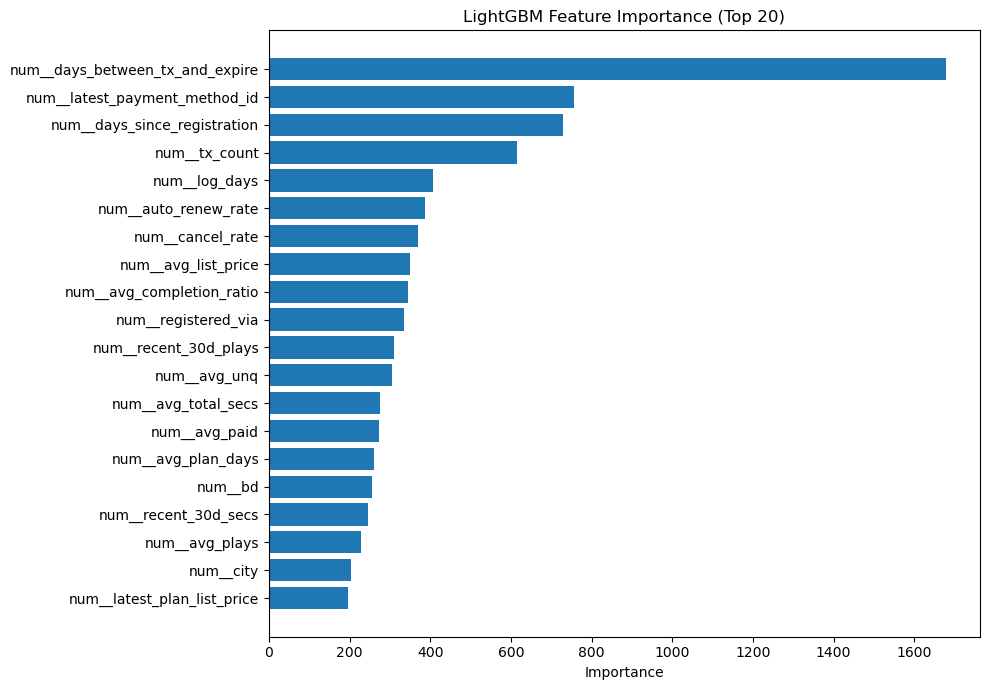

,feature,importance
6,num__days_between_tx_and_expire,1679
7,num__latest_payment_method_id,757
26,num__days_since_registration,730
0,num__tx_count,615
15,num__log_days,408
4,num__auto_renew_rate,387
5,num__cancel_rate,370
2,num__avg_list_price,349
19,num__avg_completion_ratio,344
25,num__registered_via,336


In [ ]:
lgbm_pre = lgbm_pipeline.named_steps['preprocessor']
lgbm_clf = lgbm_pipeline.named_steps['model']
feature_names_lgbm = lgbm_pre.get_feature_names_out()
feature_importance_df = pd.DataFrame({
    'feature': feature_names_lgbm,
    'importance': lgbm_clf.feature_importances_,
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 7))
top_n = 20
plot_df = feature_importance_df.head(top_n).iloc[::-1]
plt.barh(plot_df['feature'], plot_df['importance'])
plt.title(f'LightGBM Feature Importance (Top {top_n})')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

feature_importance_df.head(10)


c:\Users\tomte\anaconda3\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


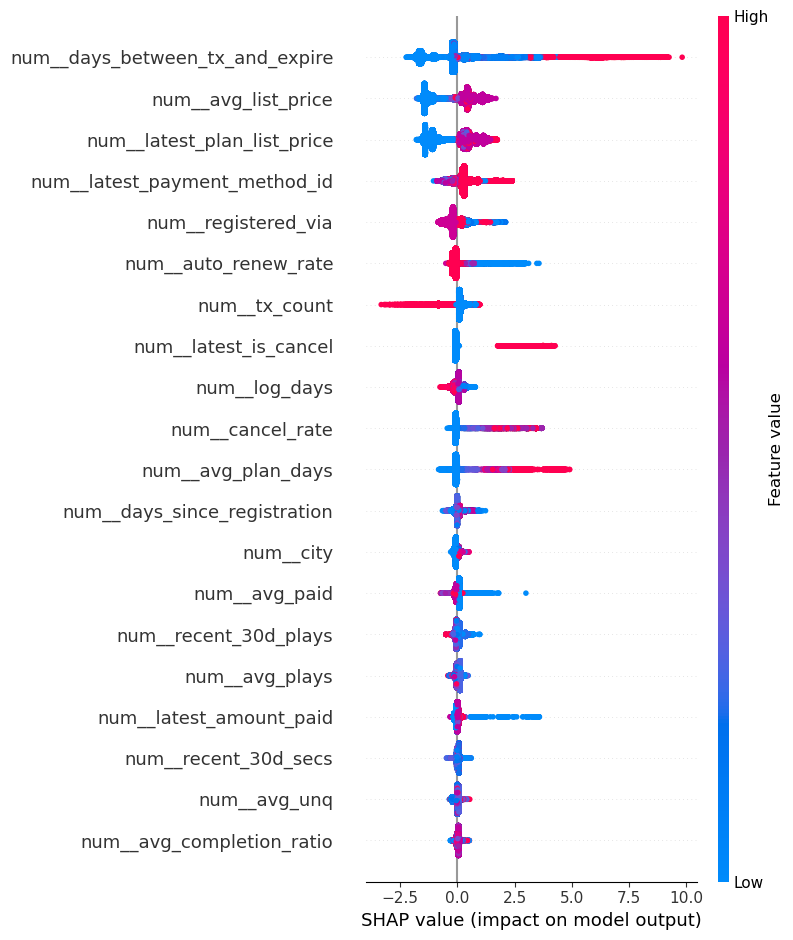

Validation example index: 0
Predicted churn probability (LightGBM): 0.0002


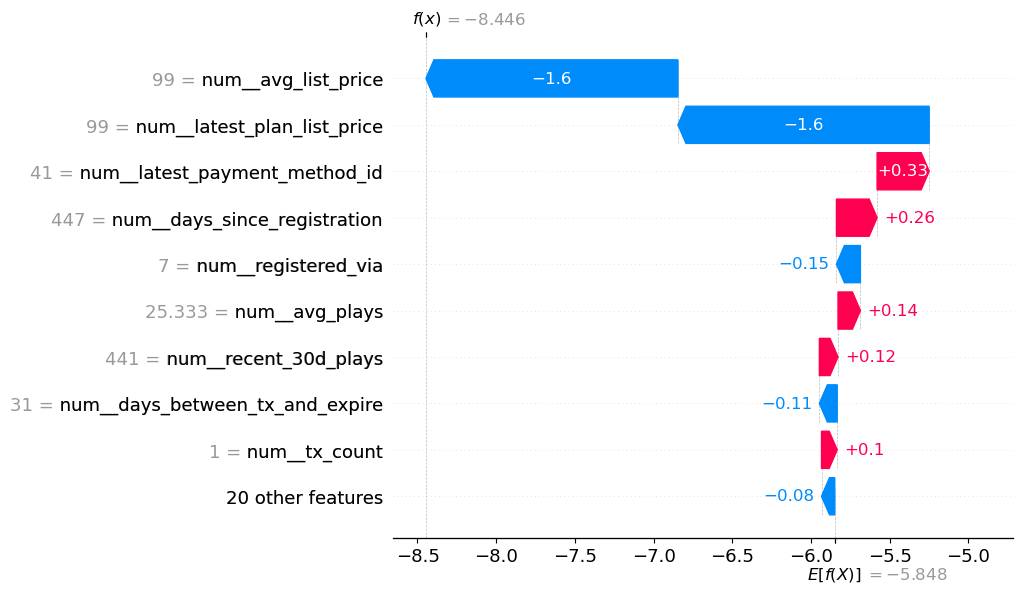

Top-10 churn drivers by mean absolute SHAP:


,feature,mean_abs_shap
6,num__days_between_tx_and_expire,1.062739
2,num__avg_list_price,0.854616
9,num__latest_plan_list_price,0.786252
7,num__latest_payment_method_id,0.360650
25,num__registered_via,0.328589
4,num__auto_renew_rate,0.273075
0,num__tx_count,0.204416
12,num__latest_is_cancel,0.163876
15,num__log_days,0.143671
5,num__cancel_rate,0.121690


In [17]:
X_train_trans = lgbm_pre.transform(X_train)
X_test_trans = lgbm_pre.transform(X_test)

X_train_trans_dense = X_train_trans.toarray() if hasattr(X_train_trans, 'toarray') else X_train_trans
X_test_trans_dense = X_test_trans.toarray() if hasattr(X_test_trans, 'toarray') else X_test_trans

explainer = shap.TreeExplainer(lgbm_clf)
shap_values_raw = explainer.shap_values(X_test_trans_dense)

if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw[1]
else:
    shap_values = shap_values_raw

X_test_shap_df = pd.DataFrame(X_test_trans_dense, columns=feature_names_lgbm)

try:
    shap.summary_plot(shap_values, X_test_shap_df, show=True)
except Exception as e:
    print('Exception:', e)

example_idx = 0
example_pred = float(lgbm_val_pred[example_idx])
print(f'Validation example index: {example_idx}')
print(f'Predicted churn probability (LightGBM): {example_pred:.4f}')

try:
    shap.plots.waterfall(shap.Explanation(
        values=shap_values[example_idx],
        base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
        data=X_test_shap_df.iloc[example_idx],
        feature_names=feature_names_lgbm,
    ))
except Exception as e:
    print('Exception:', e)
    local_contrib = pd.DataFrame({
        'feature': feature_names_lgbm,
        'shap_value': shap_values[example_idx],
        'abs_shap_value': np.abs(shap_values[example_idx]),
    }).sort_values('abs_shap_value', ascending=False)
    display(local_contrib.head(10))

mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_churn_drivers = pd.DataFrame({
    'feature': feature_names_lgbm,
    'mean_abs_shap': mean_abs_shap,
}).sort_values('mean_abs_shap', ascending=False)

print('Top-10 churn drivers by mean absolute SHAP:')
display(top_churn_drivers.head(10))


Validation example index: 122591
Predicted churn probability (LightGBM): 0.9999


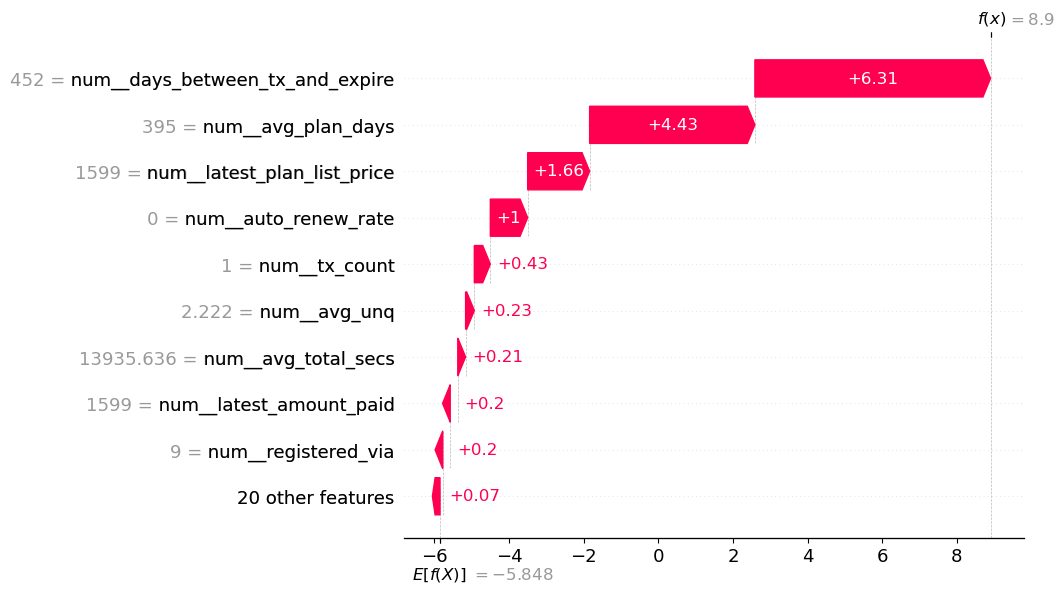

In [18]:
example_idx = 122591
example_pred = float(lgbm_val_pred[example_idx])
print(f'Validation example index: {example_idx}')
print(f'Predicted churn probability (LightGBM): {example_pred:.4f}')

try:
    shap.plots.waterfall(shap.Explanation(
        values=shap_values[example_idx],
        base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
        data=X_test_shap_df.iloc[example_idx],
        feature_names=feature_names_lgbm,
    ))
except Exception as e:
    print('Exception:', e)
    local_contrib = pd.DataFrame({
        'feature': feature_names_lgbm,
        'shap_value': shap_values[example_idx],
        'abs_shap_value': np.abs(shap_values[example_idx]),
    }).sort_values('abs_shap_value', ascending=False)
    display(local_contrib.head(10))

# 8) Active High-Risk Customers (Last Day)

In [19]:
if 'data_dir' not in locals():
    from pathlib import Path
    data_dir = Path('content')

user_logs = load_first_existing(data_dir, ["user_logs_v2.csv", "user_logs.csv"])
logs = parse_dates(user_logs)
logs = logs.sort_values(["msno", "date"]).copy()

recent_1d_window = logs[logs["date"] >= (logs["date"].max() - pd.Timedelta(days=1))]

plays_col = "engagement_total_plays" if "engagement_total_plays" in recent_1d_window.columns else "num_25"

active_1d = recent_1d_window.groupby("msno").agg(
    recent_1d_plays=(plays_col, "sum"),
    recent_1d_secs=("total_secs", "sum"),
    recent_1d_days=("date", "nunique"),
).reset_index()

high_risk_scored = scored[scored['churn_probability'] > 0.5].reset_index(drop=True)
high_risk_scored_with_features = high_risk_scored.copy()
high_risk_scored_with_features = high_risk_scored_with_features.merge(
    X_test.reset_index(drop=True),
    left_index=True,
    right_index=True,
    how='left'
)

high_risk_scored_with_features = high_risk_scored_with_features.merge(
    active_1d,
    on="msno",
    how="left"
)

# Calculate LTV (Lifetime Value) as proxy: avg_paid * tx_count
if 'avg_paid' in high_risk_scored_with_features.columns and 'tx_count' in high_risk_scored_with_features.columns:
    high_risk_scored_with_features['ltv_proxy'] = (
        high_risk_scored_with_features['avg_paid'] * high_risk_scored_with_features['tx_count']
    )
    high_risk_scored_with_features['ltv_proxy'] = high_risk_scored_with_features['ltv_proxy'].fillna(0)

active_high_risk = high_risk_scored_with_features[
    high_risk_scored_with_features['recent_1d_days'] > 0
].copy()

print(f"High-risk customers (churn_prob > 0.5): {len(high_risk_scored)}")
print(f"High-risk AND active in last 1 day: {len(active_high_risk)}")

High-risk customers (churn_prob > 0.5): 39764
High-risk AND active in last 1 day: 19712


In [20]:
ltv_threshold = active_high_risk['ltv_proxy'].quantile(0.95)
high_ltv_customers = active_high_risk[active_high_risk['ltv_proxy'] >= ltv_threshold].copy()

print(f"Total high-risk & active customers: {len(active_high_risk)}")
print(f"High-value customers (top 5% LTV): {len(high_ltv_customers)}")
print(f"\nLTV Threshold for top 5%: {ltv_threshold:.2f}")
print(f"\nTop 5 High-Value Customers:")
print(high_ltv_customers[['msno', 'churn_probability', 'ltv_proxy']].head(5))

if len(high_ltv_customers) > 0:
    high_value_customer = high_ltv_customers.sort_values('ltv_proxy', ascending=False).iloc[0]
    print(f"\n✨ SELECTED HIGH-VALUE CUSTOMER FOR PREMIUM RETENTION:")
    print(f"   MSNO: {high_value_customer['msno']}")
    print(f"   LTV: {high_value_customer['ltv_proxy']:.2f}")
    print(f"   Churn Probability: {high_value_customer['churn_probability']:.2%}")
    print(f"   Recent Activity (last day): {high_value_customer['recent_1d_days']:.0f} days active")
else:
    print("No high-value at-risk customers found in top 5% LTV group")

Total high-risk & active customers: 19712
High-value customers (top 5% LTV): 2378

LTV Threshold for top 5%: 298.00

Top 5 High-Value Customers:
                                            msno  churn_probability  ltv_proxy
9   2JQ1bl09BfsNErDTB3eE7iNfmlQu5k6xdNFUbcgMbA8=                1.0      298.0
19  Nyr+Hw95mxqL4VcT5WuH6Xx/ZaLwRysnky4+PJnUcLQ=                1.0      990.0
30  t2On/jXobrQrfS3RqX/G+zyV65YiJJGhygrQcH7qXd8=                1.0      298.0
43  DkrJK2AA3KlRpYPiNyi8GupJv8bLLbjmz2Va+lYGdZ4=                1.0      298.0
44  lAchrYRbi6rSO5ahd3pUsP3HZFBhgtpDX45K8/pNZHA=                1.0      298.0

✨ SELECTED HIGH-VALUE CUSTOMER FOR PREMIUM RETENTION:
   MSNO: fWRjXbHRYYONqS3jLB5gl3zQF+wm6aMrKs0Moo81JZ0=
   LTV: 8619.00
   Churn Probability: 100.00%
   Recent Activity (last day): 2 days active


# 9) RAG System


In [21]:
# Feature descriptions for verbose prompt generation
feature_descriptions = {
    'num__avg_plan_days': 'average subscription plan duration (months)',
    'num__avg_list_price': 'average subscription tier price',
    'num__avg_paid': 'average amount paid per billing cycle',
    'num__days_between_tx_and_expire': 'days between transaction and expiration',
    'num__latest_plan_list_price': 'latest plan list price',
    'num__auto_renew_rate': 'auto renew rate',
    'num__cancel_rate': 'cancel rate',
    'num__tx_count': 'transaction count',
    'num__avg_discount': 'average discount',
    'num__latest_discount': 'latest discount',
    'num__log_days': 'log days',
    'num__avg_plays': 'average plays',
    'num__avg_unq': 'average unique plays',
    'num__avg_total_secs': 'average total seconds',
    'num__avg_completion_ratio': 'average completion ratio',
    'num__recent_30d_plays': 'recent 30 day plays',
    'num__recent_30d_secs': 'recent 30 day seconds',
    'num__recent_30d_days': 'recent 30 day days',
    'num__days_since_registration': 'days since registration',
    'cat__city__banqiao': 'city Banqiao',
    'cat__city__beitou': 'city Beitou',
    'cat__city__changhua': 'city Changhua',
    'cat__city__chiayi': 'city Chiayi',
    'cat__city__hsinchu': 'city Hsinchu',
    'cat__city__hualien': 'city Hualien',
    'cat__city__ilan': 'city Ilan',
    'cat__city__kaohsiung': 'city Kaohsiung',
    'cat__city__keelung': 'city Keelung',
    'cat__city__miaoli': 'city Miaoli',
    'cat__city__nantou': 'city Nantou',
    'cat__city__newtaipei': 'city New Taipei',
    'cat__city__penghu': 'city Penghu',
    'cat__city__pingtung': 'city Pingtung',
    'cat__city__taichung': 'city Taichung',
    'cat__city__tainan': 'city Tainan',
    'cat__city__taipei': 'city Taipei',
    'cat__city__taitung': 'city Taitung',
    'cat__city__taoyuan': 'city Taoyuan',
    'cat__city__yilan': 'city Yilan',
    'cat__city__yunlin': 'city Yunlin',
    'cat__gender__female': 'gender female',
    'cat__gender__male': 'gender male',
    'cat__registered_via__3': 'registered via 3',
    'cat__registered_via__4': 'registered via 4',
    'cat__registered_via__7': 'registered via 7',
    'cat__registered_via__9': 'registered via 9',
    'cat__registered_via__13': 'registered via 13',
    'cat__latest_payment_method_id__2': 'latest payment method 2',
    'cat__latest_payment_method_id__3': 'latest payment method 3',
    'cat__latest_payment_method_id__4': 'latest payment method 4',
    'cat__latest_payment_method_id__5': 'latest payment method 5',
    'cat__latest_payment_method_id__6': 'latest payment method 6',
    'cat__latest_payment_method_id__8': 'latest payment method 8',
    'cat__latest_payment_method_id__10': 'latest payment method 10',
    'cat__latest_payment_method_id__11': 'latest payment method 11',
    'cat__latest_payment_method_id__12': 'latest payment method 12',
    'cat__latest_payment_method_id__13': 'latest payment method 13',
    'cat__latest_payment_method_id__14': 'latest payment method 14',
    'cat__latest_payment_method_id__15': 'latest payment method 15',
    'cat__latest_payment_method_id__16': 'latest payment method 16',
    'cat__latest_payment_method_id__17': 'latest payment method 17',
    'cat__latest_payment_method_id__18': 'latest payment method 18',
    'cat__latest_payment_method_id__19': 'latest payment method 19',
    'cat__latest_payment_method_id__20': 'latest payment method 20',
    'cat__latest_payment_method_id__21': 'latest payment method 21',
    'cat__latest_payment_method_id__22': 'latest payment method 22',
    'cat__latest_payment_method_id__23': 'latest payment method 23',
    'cat__latest_payment_method_id__24': 'latest payment method 24',
    'cat__latest_payment_method_id__25': 'latest payment method 25',
    'cat__latest_payment_method_id__26': 'latest payment method 26',
    'cat__latest_payment_method_id__27': 'latest payment method 27',
    'cat__latest_payment_method_id__28': 'latest payment method 28',
    'cat__latest_payment_method_id__29': 'latest payment method 29',
    'cat__latest_payment_method_id__30': 'latest payment method 30',
    'cat__latest_payment_method_id__31': 'latest payment method 31',
    'cat__latest_payment_method_id__32': 'latest payment method 32',
    'cat__latest_payment_method_id__33': 'latest payment method 33',
    'cat__latest_payment_method_id__34': 'latest payment method 34',
    'cat__latest_payment_method_id__35': 'latest payment method 35',
    'cat__latest_payment_method_id__36': 'latest payment method 36',
    'cat__latest_payment_method_id__37': 'latest payment method 36',
    'cat__latest_payment_method_id__38': 'latest payment method 38',
    'cat__latest_payment_method_id__39': 'latest payment method 39',
    'cat__latest_payment_method_id__40': 'latest payment method 40',
    'cat__latest_payment_method_id__41': 'latest payment method 41',
}

In [22]:
import sys

from rag_knowledge_base import (
    RAG_KNOWLEDGE_BASE,
    retrieve_relevant_knowledge,
    get_support_prompt_enhancement
)

print(" RAG KNOWLEDGE BASE STRUCTURE:")
print(f"   - Churn Reason Categories: {list(RAG_KNOWLEDGE_BASE['churn_reasons'].keys())}")
print(f"   - Product Features: {list(RAG_KNOWLEDGE_BASE['product_features'].keys())}")
print(f"   - Customer Segments: {list(RAG_KNOWLEDGE_BASE['customer_segments'].keys())}")
print(f"   - Script Templates: {list(RAG_KNOWLEDGE_BASE['script_templates'].keys())}")

example_knowledge = retrieve_relevant_knowledge("low_engagement", "high_value")
print("\n Example RAG Retrieval - Low Engagement (HIGH-VALUE Customer):")
print(f"   Description: {example_knowledge['description']}")
print(f"   Indicators: {example_knowledge['indicators']}")
print(f"   Recommended Actions:")
for action in example_knowledge['actions']:
    print(f"      • {action}")


 RAG KNOWLEDGE BASE STRUCTURE:
   - Churn Reason Categories: ['low_engagement', 'payment_friction', 'subscription_tier_mismatch', 'competition_pressure', 'high_value_retention']
   - Product Features: ['discovery', 'social', 'premium_features', 'podcasts']
   - Customer Segments: ['casual_listener', 'power_user', 'subscriber_fluctuator', 'high_value_loyal']
   - Script Templates: ['engagement_recovery', 'payment_recovery', 'vip_retention']

 Example RAG Retrieval - Low Engagement (HIGH-VALUE Customer):
   Description: Customer shows minimal or declining music plays and listening time
   Indicators: ['avg_plays < 5', 'avg_completion_ratio < 0.3', 'recent_30d_plays near 0']
   Recommended Actions:
      • Assign human playlist curator for weekly curated mixes
      • Grant 1-month free high-fidelity audio tier upgrade
      • Exclusive early access to unreleased tracks from favorite artists


In [30]:
import requests
import base64
import uuid

with open('content/key', 'r') as f:
    auth = f.read().strip()

headers = {
    "Authorization": f"Basic {auth}",
    "RqUID": str(uuid.uuid4()),
    "Content-Type": "application/x-www-form-urlencoded"
}
data = "scope=GIGACHAT_API_PERS"
response = requests.post("https://ngw.devices.sberbank.ru:9443/api/v2/oauth", headers=headers, data=data, verify=False)
if response.status_code != 200:
    print(f"Auth failed: {response.status_code} {response.text}")
else:
    token = response.json()["access_token"]
    print("Token obtained successfully")

    

Token obtained successfully


c:\Users\tomte\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'ngw.devices.sberbank.ru'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


In [ ]:
def extract_churn_factors_from_features(customer_row: pd.Series, feature_descriptions: dict) -> list:
    churn_factors = []
    
    if 'top_reasons' in customer_row.index:
        reasons_str = customer_row['top_reasons']
        if isinstance(reasons_str, str) and reasons_str != "No strong positive churn signals":
            reasons_list = reasons_str.split('; ')
            for reason in reasons_list:
                if ' (' in reason:
                    feat = reason.split(' (')[0]
                    # Map feature to churn category
                    if 'cancel' in feat or 'payment' in feat:
                        if 'payment_friction' not in churn_factors:
                            churn_factors.append('payment_friction')
                    elif 'plays' in feat or 'completion' in feat or 'engagement' in feat:
                        if 'low_engagement' not in churn_factors:
                            churn_factors.append('low_engagement')
                    elif 'subscription' in feat or 'plan' in feat:
                        if 'subscription_tier_mismatch' not in churn_factors:
                            churn_factors.append('subscription_tier_mismatch')
    
    if 'avg_plays' in customer_row.index and customer_row['avg_plays'] < 5:
        if 'low_engagement' not in churn_factors:
            churn_factors.append('low_engagement')
    
    if 'ltv_proxy' in customer_row.index:
        ltv_threshold = active_high_risk['ltv_proxy'].quantile(0.95) if len(active_high_risk) > 0 else 1000
        if customer_row['ltv_proxy'] >= ltv_threshold and customer_row['churn_probability'] > 0.5:
            if 'high_value_retention' not in churn_factors:
                churn_factors.append('high_value_retention')
    
    return churn_factors if churn_factors else ['low_engagement']  # default


def build_rag_enriched_prompt(customer_row: pd.Series, feature_descriptions: dict, is_high_value: bool = False) -> str:
    customer_msno = customer_row['msno']
    churn_prob = customer_row['churn_probability']
    ltv = customer_row.get('ltv_proxy', 0)
    
    # Extract churn factors using RAG
    churn_factors = extract_churn_factors_from_features(customer_row, feature_descriptions)
    
    # Build base prompt
    prompt = f"MUSIC STREAMING CUSTOMER RETENTION ANALYSIS\n"
    prompt += f"Customer ID: {customer_msno}\n"
    prompt += f"Churn Risk: {churn_prob:.1%}\n"
    
    if is_high_value:
        prompt += f" VIP TIER - Lifetime Value: ${ltv:.2f} (TOP 5%)\n"
    else:
        prompt += f"Estimated Lifetime Value: ${ltv:.2f}\n"
    
    # Add identified churn factors
    prompt += f"\nPRIMARY CHURN FACTORS: {', '.join([f.replace('_', ' ').title() for f in churn_factors])}\n"
    
    # Add RAG-enriched knowledge
    rag_enhancement = get_support_prompt_enhancement(
        churn_factors,
        customer_value="high_value" if is_high_value else "standard",
        ltv=ltv
    )
    prompt += rag_enhancement
    
    # Add action prompt
    prompt += "\n\nSUPPORT ACTION RECOMMENDATION:"
    prompt += "\nBased on the churn factors and customer value tier, prioritize these actions:"
    prompt += "\n1. Immediate: [Most impactful action from RAG knowledge base]"
    prompt += "\n2. Follow-up: [Secondary engagement tactic]"
    prompt += "\n3. Long-term: [Loyalty/relationship building]"
    
    return prompt


print("Churn factor extraction and RAG-enriched prompt builders loaded")


Churn factor extraction and RAG-enriched prompt builders loaded


In [28]:
test_customers = []

if len(active_high_risk) > 0:
    standard_cust = active_high_risk[
        (active_high_risk['avg_plays'] < 10) &
        (active_high_risk['ltv_proxy'] < active_high_risk['ltv_proxy'].quantile(0.95))
    ].iloc[0] if len(active_high_risk[
        (active_high_risk['avg_plays'] < 10) &
        (active_high_risk['ltv_proxy'] < active_high_risk['ltv_proxy'].quantile(0.95))
    ]) > 0 else active_high_risk.iloc[0]
    test_customers.append(("Standard Customer", standard_cust, False))

if len(active_high_risk) > 0:
    ltv_threshold = active_high_risk['ltv_proxy'].quantile(0.95)
    high_value_customers = active_high_risk[active_high_risk['ltv_proxy'] >= ltv_threshold]
    if len(high_value_customers) > 0:
        hv_cust = high_value_customers.iloc[0]
        test_customers.append(("High-Value VIP Customer", hv_cust, True))

print(f"\nGenerating RAG-enriched prompts for {len(test_customers)} test customer(s)...\n")

rag_prompts = {}
for customer_label, customer_row, is_high_value in test_customers:
    rag_prompt = build_rag_enriched_prompt(customer_row, feature_descriptions, is_high_value)
    rag_prompts[customer_label] = rag_prompt
    
    print(f" PROMPT FOR: {customer_label}")
    print(rag_prompt)

print(f"Generated {len(rag_prompts)} RAG-enriched prompts")
print(f"Prompts ready for GigaChat/LLM integration")



Generating RAG-enriched prompts for 2 test customer(s)...

 PROMPT FOR: Standard Customer
MUSIC STREAMING CUSTOMER RETENTION ANALYSIS
Customer ID: NSAa9MDSBy47FDiOD+mQDA5pbH284PfDTNCUWqq732o=
Churn Risk: 100.0%
Estimated Lifetime Value: $149.00

PRIMARY CHURN FACTORS: Subscription Tier Mismatch


=== RAG SUPPORT KNOWLEDGE BASE ===
Customer Type: STANDARD
Lifetime Value: $149.00

RELEVANT SUPPORT STRATEGIES:

1. SUBSCRIPTION_TIER_MISMATCH
   Context: Customer subscribed to low or mid tier but shows high engagement patterns
   Recommended Actions:
   - Recommend premium upgrade with feature comparison
   - Offer 1-month discounted premium trial

KEY METRICS GUIDE:
- churn_probability: Model confidence (0-100%) that customer will leave within 30 days. >60% requires immediate intervention.
- avg_plays: Average songs played per unit time. Low (<5) indicates engagement problem.
- ltv_proxy: Lifetime Value estimate. Top 5% (95th percentile) are VIP targets.

SUPPORT ACTION RECOMMENDATION:
Ba

In [31]:
if token:
    print("RUNNING RAG-ENRICHED GIGACHAT ANALYSIS")
    print("=" * 80)
    
    for customer_label, (cust_name, customer_row, is_high_value) in enumerate(
        [("Standard Customer", test_customers[0][1], test_customers[0][2])] if len(test_customers) > 0 else []
    ):
        rag_prompt = rag_prompts.get("Standard Customer" if customer_label == 0 else "High-Value VIP Customer")
        if not rag_prompt:
            continue
        
        # Enhance with instruction
        full_prompt = rag_prompt + "\n\nProvide concise, actionable retention strategy for support agents."
        
        chat_headers = {
            "Authorization": f"Bearer {token}",
            "Content-Type": "application/json",
            "RqUID": str(uuid.uuid4())
        }
        messages = [{"role": "user", "content": full_prompt}]
        data = {"model": "GigaChat", "messages": messages, "temperature": 0.7}
        
        try:
            response = requests.post(
                "https://gigachat.devices.sberbank.ru/api/v1/chat/completions",
                headers=chat_headers,
                json=data,
                verify=False
            )
            if response.status_code == 200:
                result = response.json()
                print(f"\nRAG-ENRICHED RESPONSE FOR: Test Customer {customer_label + 1}")
                print("─" * 80)
                print(result["choices"][0]["message"]["content"])
                print("─" * 80)
            else:
                print(f"API Error {response.status_code}: {response.text[:200]}")
        except Exception as e:
            print(f"Connection Error: {str(e)[:200]}")
else:
    print("GigaChat token not initialized in this session")
    print("RAG-enriched prompts have been generated and are ready for API integration")
    print("\nGenerated Prompts Summary:")
    for label in rag_prompts:
        print(f"{label}: {len(rag_prompts[label])} characters")


RUNNING RAG-ENRICHED GIGACHAT ANALYSIS


c:\Users\tomte\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'gigachat.devices.sberbank.ru'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(



RAG-ENRICHED RESPONSE FOR: Test Customer 1
────────────────────────────────────────────────────────────────────────────────
### Retention Strategy Plan for Customer NSAa9MDSBy47FDiOD+mQDA5pbH284PfDTNCUWqq732o=

---

#### **Primary Churn Factor:** Subscription Tier Mismatch  
**Churn Probability:** 100.0%  
**Engagement Metrics:** High Engagement Patterns  
**LTV Proxy:** $149.00 (Top 5% VIP Target)

---

### **Support Action Recommendations**

1. **Immediate Action: Premium Upgrade Recommendation**
   - **Action:** Recommend a premium subscription plan based on detailed feature comparisons between current and upgraded plans.
     - **Offer:** A 1-month discounted premium trial period.
   - **Benefit:** Aligns the customer's usage behavior with their expected value by upgrading them to a more suitable plan.
   
2. **Follow-up Action: Personalized Communication**
   - **Action:** Send an email or in-app message outlining the benefits of the new plan and highlighting features they may ha